In [3]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from hattmapper import HATTMapper, PaulihedralDriver, FermihedralMapper, TernaryTreeMapper, load_molecule, pauli_weight, Simulation, RustiqDriver, TetrisDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import BravyiKitaevMapper, JordanWignerMapper
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from typing import Literal

plt.style.use("classic")

molecules = (
    ("H_2", "sto3g", False),
    ("H_2", "sto3g", True),
    ("H_2", "631g", False),
    ("H_2", "631g", True),
    ("LiH", "sto3g", False),
    ("LiH", "sto3g", True),
    ("NH", "sto3g", True),
    ("NH", "631g", False),
    ("NH", "631g", True),
    ("BeH_2", "sto3g", True),
    ("O_2", "sto3g", False),
)

## Table I

May take more than 1hr to compile and optimize circuits. The results are pretty printed in table format.

In [2]:
table = PrettyTable([f"{i}" for i in range(17)], header=False, hrules=True)
table.add_row(["", "", "Pauli Weight", "", "", "", "", "CNOT", "", "", "", "", "Depth", "", "", "", ""])
table.add_row(["Case", "Modes", "JW", "BK", "BTT", "FH", "HATT", "JW", "BK", "BTT", "FH", "HATT", "JW", "BK", "BTT", "FH", "HATT"])

for n, (casename, basis, freezecore) in enumerate(molecules):
    full_casename = f"{casename} {basis}" + (" frz" if freezecore else "")

    print(full_casename)

    problem = PySCFDriver(
        atom=load_molecule(f"tests/{casename}.json"),
        basis=basis,
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    ).run()

    if freezecore:
        problem = FreezeCoreTransformer(freeze_core=True).transform(problem)

    hamiltonian: FermionicOp = problem.hamiltonian.second_q_op() # type: ignore

    ttmapper = HATTMapper(hamiltonian)

    mappers = (
        JordanWignerMapper(),
        BravyiKitaevMapper(),
        TernaryTreeMapper(),
        FermihedralMapper.molecule(),
        ttmapper,
    )

    weights = []
    cnots = []
    depths = []

    for m in mappers:
        weight = (
            "--"
            if isinstance(m, FermihedralMapper)
            and not m.solved(hamiltonian.register_length)
            else str(pauli_weight(hamiltonian, m))
        )

        weights.append(weight)

        complexity = (
            "--"
            if isinstance(m, FermihedralMapper)
            and not m.solved(hamiltonian.register_length)
            else PaulihedralDriver(hamiltonian, m).summary
        )

        if complexity == "--":
            cnots.append("--")
            depths.append("--")
        else:
            complexity = complexity.split("/")
            cnots.append(complexity[0])
            depths.append(complexity[2])
    
    table.add_row([full_casename, hamiltonian.register_length, *weights, *cnots, *depths])

print(table)

H_2 sto3g


H_2 sto3g frz


H_2 631g


H_2 631g frz


LiH sto3g


...

NH 631g


NH 631g frz


BeH_2 sto3g frz


O_2 sto3g


+-----------------+-------+--------------+-------+-------+------+-------+-------+-------+-------+------+-------+-------+-------+-------+------+-------+
|                 |       | Pauli Weight |       |       |      |       |  CNOT |       |       |      |       | Depth |       |       |      |       |
+-----------------+-------+--------------+-------+-------+------+-------+-------+-------+-------+------+-------+-------+-------+-------+------+-------+
|       Case      | Modes |      JW      |   BK  |  BTT  |  FH  |  HATT |   JW  |   BK  |  BTT  |  FH  |  HATT |   JW  |   BK  |  BTT  |  FH  |  HATT |
+-----------------+-------+--------------+-------+-------+------+-------+-------+-------+-------+------+-------+-------+-------+-------+------+-------+
|    H_2 sto3g    |   4   |      32      |   34  |   36  |  32  |   32  |   21  |   25  |   33  |  22  |   21  |   34  |   36  |   52  |  34  |   34  |
+-----------------+-------+--------------+-------+-------+------+-------+-------+-------

## Figure 10

May take more than 30mins to simulate $LiH$. However, $H_2$ is fast and should be expected within minutes.

In [3]:
class Result:
    def __init__(self, x: int, y: int, base: float) -> None:
        self.bias = np.zeros((x, y))
        self.var = np.zeros((x, y))
        self.base = base

    def __setitem__(self, pos, value):
        e, var = value
        self.bias[pos] = e - self.base
        self.var[pos] = var

    def random(self):
        self.bias = np.random.random(self.bias.shape)
        self.var = np.random.random(self.var.shape)

    @property
    def max_bias(self) -> float:
        return self.bias.max()

    @property
    def min_bias(self) -> float:
        return self.bias.min()

    @property
    def max_var(self) -> float:
        return self.var.max()

    @property
    def min_var(self) -> float:
        return self.var.min()

def simulate_molecule(molecule: str):
    if molecule == "H2":
        hamiltonian: FermionicOp = (
            PySCFDriver(
                atom="H 0 0 0; H 0 0 0.735",
                basis="sto3g",
                charge=0,
                spin=0,
                unit=DistanceUnit.ANGSTROM,
            )
            .run()
            .hamiltonian.second_q_op()
        )
    else:
        problem = PySCFDriver(
            atom="H 0 0 0; Li 0 0 1.6",
            basis="sto3g",
            charge=0,
            spin=0,
            unit=DistanceUnit.ANGSTROM,
        ).run()

        hamiltonian: FermionicOp = ( # type: ignore
            FreezeCoreTransformer(freeze_core=True, remove_orbitals=[-3, 3, 2, -2])
            .transform(problem)
            .hamiltonian.second_q_op()
        )
    
    ttmapper = HATTMapper(hamiltonian)

    ttsim = Simulation(hamiltonian, ttmapper)
    jwsim = Simulation(hamiltonian, JordanWignerMapper())
    bksim = Simulation(hamiltonian, BravyiKitaevMapper())
    bttsim = Simulation(hamiltonian, TernaryTreeMapper())
    fhsim = Simulation(hamiltonian, FermihedralMapper.molecule())


    err_1qs = np.arange(0.0001, 0.001, 0.00005)
    err_2qs = np.arange(0.001, 0.01, 0.0005)

    tt_result = Result(len(err_1qs), len(err_2qs), ttsim.ground_energy)
    jw_result = Result(len(err_1qs), len(err_2qs), jwsim.ground_energy)
    bk_result = Result(len(err_1qs), len(err_2qs), bksim.ground_energy)
    btt_result = Result(len(err_1qs), len(err_2qs), bttsim.ground_energy)
    fh_result = Result(len(err_1qs), len(err_2qs), fhsim.ground_energy)

    for i in tqdm(range(len(err_1qs))):
        for j in range(len(err_2qs)):

            tt_result[i, j] = ttsim.simulate(
                depolarerr_1q=err_1qs[i], depolarerr_2q=err_2qs[j], quiet=True
            )
            jw_result[i, j] = jwsim.simulate(
                depolarerr_1q=err_1qs[i], depolarerr_2q=err_2qs[j], quiet=True
            )
            bk_result[i, j] = bksim.simulate(
                depolarerr_1q=err_1qs[i], depolarerr_2q=err_2qs[j], quiet=True
            )
            btt_result[i, j] = bttsim.simulate(
                depolarerr_1q=err_1qs[i], depolarerr_2q=err_2qs[j], quiet=True
            )
            fh_result[i, j] = fhsim.simulate(
                depolarerr_1q=err_1qs[i], depolarerr_2q=err_2qs[j], quiet=True
            )
    
    def plot(vorb: Literal["var", "bias"]):
        name = "Bias" if vorb == "bias" else "Variance"
        if vorb == "bias":
            maxvalue = max(tt_result.max_bias, jw_result.max_bias, bk_result.max_bias)
            minvalue = min(tt_result.min_bias, jw_result.min_bias, bk_result.min_bias)
        else:
            maxvalue = max(tt_result.max_var, jw_result.max_var, bk_result.max_var)
            minvalue = min(tt_result.min_var, jw_result.min_var, bk_result.min_var)
        plt.clf()
        plt.subplots(1, 5, figsize=(12, 4), layout="constrained")
        plt.suptitle(f"{name}-{molecule}")
        plt.subplot(1, 5, 1)
        plt.title("JW")
        plt.imshow(
            getattr(jw_result, vorb), interpolation="nearest", vmax=maxvalue, vmin=minvalue
        )
        plt.xticks([])
        plt.yticks([])
        plt.subplot(1, 5, 2)
        plt.title("BK")
        plt.imshow(
            getattr(bk_result, vorb), interpolation="nearest", vmax=maxvalue, vmin=minvalue
        )
        plt.xticks([])
        plt.yticks([])
        plt.subplot(1, 5, 3)
        plt.title("BTT")
        im = plt.imshow(
            getattr(btt_result, vorb), interpolation="nearest", vmax=maxvalue, vmin=minvalue
        )
        plt.xticks([])
        plt.yticks([])
        plt.subplot(1, 5, 4)
        plt.title("FH")
        im = plt.imshow(
            getattr(fh_result, vorb), interpolation="nearest", vmax=maxvalue, vmin=minvalue
        )
        plt.xticks([])
        plt.yticks([])
        plt.subplot(1, 5, 5)
        plt.title("HATT")
        im = plt.imshow(
            getattr(tt_result, vorb), interpolation="nearest", vmax=maxvalue, vmin=minvalue
        )
        plt.xticks([])
        plt.yticks([])
        plt.colorbar(im, fraction=0.05, pad=0.04, aspect=20)
        plt.show()


    plot("bias")
    plot("var")

Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.857275030202381
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 40
    Gates = 33 U3, 23 CX, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.857275030202383
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 52
    Gates = 34 U3, 33 CX, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.8572750302023808
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 51
    Gates = 35 CX, 23 U3, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:
    Ground 

100%|██████████| 18/18 [00:52<00:00,  2.93s/it]


<Figure size 640x480 with 0 Axes>

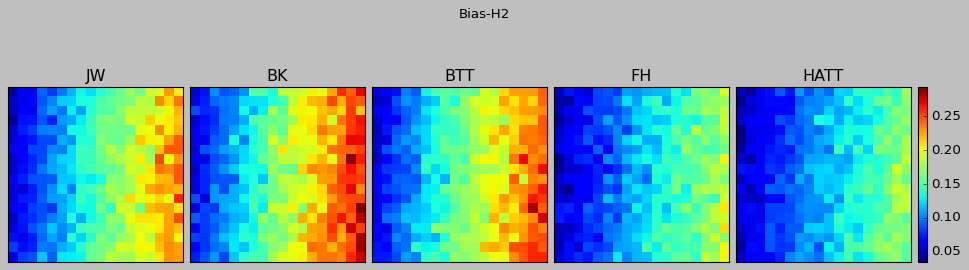

<Figure size 640x480 with 0 Axes>

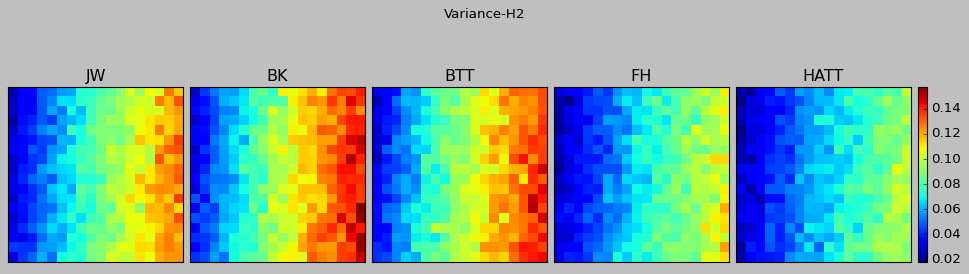

In [4]:
simulate_molecule("H2")

Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.0730686425519413
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 300
    Gates = 221 U3, 190 CX, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.0730686425519425
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 325
    Gates = 227 CX, 208 U3, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:
    Ground energy = -1.0730686425519416
  Construct and transpile Pauli evolution:
    Time duration    = 1.0
    Basis gates      = cx, u3, set_statevector
    Synthesis method = LieTrotter
  Circuit summary:
    Depth = 360
    Gates = 263 CX, 203 U3, 1 SET_STATEVECTOR
Hamiltonian simulation:
  Solve ground state:


100%|██████████| 18/18 [24:26<00:00, 81.45s/it]


<Figure size 640x480 with 0 Axes>

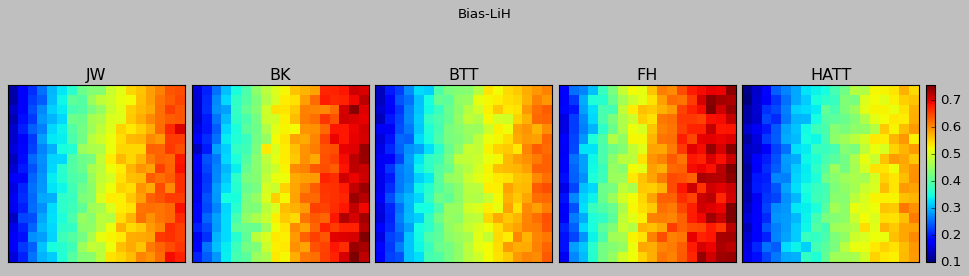

<Figure size 640x480 with 0 Axes>

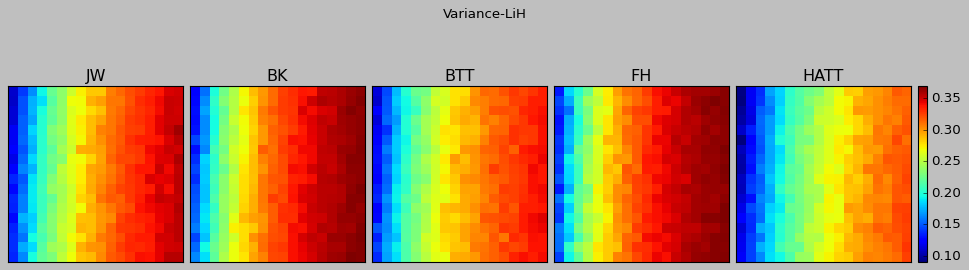

In [5]:
simulate_molecule("LiH")

## Table VI

May take more than 1hr to compile and optimize circuits. The results are pretty printed in table format.

In [12]:
from termcolor import colored

def architecture(arch: str):
    print(f"Architecture: {colored(arch.capitalize(), 'cyan', attrs=['bold'])}")

    table = PrettyTable([f"{i}" for i in range(7)], header=False, hrules=True)
    table.add_row(["", "CNOT", "", "U3", "", "Depth", ""])
    table.add_row(["Case", "JW", "HATT", "JW", "HATT", "JW", "HATT"])

    for n, (casename, basis, freezecore) in enumerate(molecules):
        full_casename = f"{casename} {basis}" + (" frz" if freezecore else "")

        print(full_casename)

        problem = PySCFDriver(
            atom=load_molecule(f"tests/{casename}.json"),
            basis=basis,
            charge=0,
            spin=0,
            unit=DistanceUnit.ANGSTROM,
        ).run()

        if freezecore:
            problem = FreezeCoreTransformer(freeze_core=True).transform(problem)

        hamiltonian: FermionicOp = problem.hamiltonian.second_q_op() # type: ignore

        ttmapper = HATTMapper(hamiltonian)

        mappers = (
            JordanWignerMapper(),
            ttmapper,
        )

        cnots = []
        u3s = []
        depths = []

        for m in mappers:

            complexity = TetrisDriver(hamiltonian, m, arch=arch).summary

            cnots.append(complexity["cx"])
            u3s.append(complexity["u3"])
            depths.append(complexity["depth"])
        
        table.add_row([full_casename, *cnots, *u3s, *depths])

    print(table)

In [13]:
architecture("manhattan")

Architecture: Manhattan
H_2 sto3g


H_2 sto3g frz


H_2 631g


H_2 631g frz


LiH sto3g


...

NH 631g


NH 631g frz


BeH_2 sto3g frz


O_2 sto3g


+-----------------+--------+--------+-------+-------+--------+--------+
|                 |  CNOT  |        |   U3  |       | Depth  |        |
+-----------------+--------+--------+-------+-------+--------+--------+
|       Case      |   JW   |  HATT  |   JW  |  HATT |   JW   |  HATT  |
+-----------------+--------+--------+-------+-------+--------+--------+
|    H_2 sto3g    |   42   |   38   |   40  |   37  |   61   |   56   |
+-----------------+--------+--------+-------+-------+--------+--------+
|  H_2 sto3g frz  |   40   |   38   |   47  |   37  |   62   |   56   |
+-----------------+--------+--------+-------+-------+--------+--------+
|     H_2 631g    |  1432  |  1271  |  1304 |  1135 |  1703  |  1506  |
+-----------------+--------+--------+-------+-------+--------+--------+
|   H_2 631g frz  |  1433  |  1699  |  1303 |  1178 |  1697  |  1801  |
+-----------------+--------+--------+-------+-------+--------+--------+
|    LiH sto3g    |  6928  |  6960  |  4873 |  4431 |  7173  |  

In [14]:
architecture("sycamore")

Architecture: Sycamore
H_2 sto3g


H_2 sto3g frz


H_2 631g


H_2 631g frz


LiH sto3g


...

NH 631g


NH 631g frz


BeH_2 sto3g frz


O_2 sto3g


+-----------------+-------+-------+-------+-------+-------+-------+
|                 |  CNOT |       |   U3  |       | Depth |       |
+-----------------+-------+-------+-------+-------+-------+-------+
|       Case      |   JW  |  HATT |   JW  |  HATT |   JW  |  HATT |
+-----------------+-------+-------+-------+-------+-------+-------+
|    H_2 sto3g    |   42  |   38  |   40  |   37  |   56  |   56  |
+-----------------+-------+-------+-------+-------+-------+-------+
|  H_2 sto3g frz  |   40  |   38  |   46  |   37  |   60  |   56  |
+-----------------+-------+-------+-------+-------+-------+-------+
|     H_2 631g    |  1095 |  1216 |  1011 |  995  |  1370 |  1367 |
+-----------------+-------+-------+-------+-------+-------+-------+
|   H_2 631g frz  |  1130 |  1170 |  991  |  990  |  1374 |  1332 |
+-----------------+-------+-------+-------+-------+-------+-------+
|    LiH sto3g    |  5671 |  5742 |  4018 |  3607 |  6097 |  6021 |
+-----------------+-------+-------+-------+-----

In [15]:
architecture("montreal")

Architecture: Montreal
H_2 sto3g


H_2 sto3g frz


H_2 631g


H_2 631g frz


LiH sto3g


...

NH 631g


NH 631g frz


BeH_2 sto3g frz


O_2 sto3g


+-----------------+--------+--------+-------+-------+--------+--------+
|                 |  CNOT  |        |   U3  |       | Depth  |        |
+-----------------+--------+--------+-------+-------+--------+--------+
|       Case      |   JW   |  HATT  |   JW  |  HATT |   JW   |  HATT  |
+-----------------+--------+--------+-------+-------+--------+--------+
|    H_2 sto3g    |   42   |   38   |   40  |   37  |   61   |   56   |
+-----------------+--------+--------+-------+-------+--------+--------+
|  H_2 sto3g frz  |   42   |   38   |   40  |   37  |   61   |   56   |
+-----------------+--------+--------+-------+-------+--------+--------+
|     H_2 631g    |  1452  |  1671  |  1269 |  1280 |  1721  |  1783  |
+-----------------+--------+--------+-------+-------+--------+--------+
|   H_2 631g frz  |  1430  |  1283  |  1313 |  1140 |  1701  |  1524  |
+-----------------+--------+--------+-------+-------+--------+--------+
|    LiH sto3g    |  7060  |  7663  |  4799 |  4775 |  7181  |  

## Table V

May take more than 1hr to compile and optimize circuits. The results are pretty printed in table format.

In [16]:
table = PrettyTable([f"{i}" for i in range(7)], header=False, hrules=True)
table.add_row(["", "CNOT", "", "U3", "", "Depth", ""])
table.add_row(["Case", "JW", "HATT", "JW", "HATT", "JW", "HATT"])

for n, (casename, basis, freezecore) in enumerate(molecules):
    full_casename = f"{casename} {basis}" + (" frz" if freezecore else "")

    print(full_casename)

    problem = PySCFDriver(
        atom=load_molecule(f"tests/{casename}.json"),
        basis=basis,
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    ).run()

    if freezecore:
        problem = FreezeCoreTransformer(freeze_core=True).transform(problem)

    hamiltonian: FermionicOp = problem.hamiltonian.second_q_op() # type: ignore

    ttmapper = HATTMapper(hamiltonian)

    mappers = (
        JordanWignerMapper(),
        ttmapper,
    )

    cnots = []
    u3s = []
    depths = []

    for m in mappers:

        complexity =RustiqDriver(hamiltonian, m, metric="depth").summary

        cnots.append(complexity["cx"])
        u3s.append(complexity["u3"])
        depths.append(complexity["depth"])
    
    table.add_row([full_casename, *cnots, *u3s, *depths])

print(table)

H_2 sto3g


H_2 sto3g frz


H_2 631g


H_2 631g frz


LiH sto3g


...

NH 631g


NH 631g frz


BeH_2 sto3g frz


O_2 sto3g


+-----------------+-------+-------+-------+-------+-------+------+
|                 |  CNOT |       |   U3  |       | Depth |      |
+-----------------+-------+-------+-------+-------+-------+------+
|       Case      |   JW  |  HATT |   JW  |  HATT |   JW  | HATT |
+-----------------+-------+-------+-------+-------+-------+------+
|    H_2 sto3g    |   7   |   7   |   6   |   2   |   7   |  7   |
+-----------------+-------+-------+-------+-------+-------+------+
|  H_2 sto3g frz  |   7   |   7   |   6   |   2   |   7   |  7   |
+-----------------+-------+-------+-------+-------+-------+------+
|     H_2 631g    |  217  |  211  |  180  |  175  |  164  | 149  |
+-----------------+-------+-------+-------+-------+-------+------+
|   H_2 631g frz  |  217  |  220  |  180  |  185  |  164  | 171  |
+-----------------+-------+-------+-------+-------+-------+------+
|    LiH sto3g    |  1348 |  1208 |  1031 |  908  |  625  | 551  |
+-----------------+-------+-------+-------+-------+-------+---